## Download resources

Please download the required resources from **Figshare** and place them in the following locations (relative to the project root):

- **Dataset** → `./dataset/`
- **Motif priors** → `./utils/motif_prior/output/motif_prior/`
- **Pretrained models** → `./results/model/`

After the folders are in place, you can run the notebook cells below.

In [1]:
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
os.chdir(PROJECT_ROOT)

print("CWD =", os.getcwd())

CWD = /fs1/private/user/wangyubo/code/BRIDGE_folder/BRIDGE_reproducibility


In [2]:
import random
import argparse
import subprocess
import sys

# BRIDGE root directory
BRIDGE_ROOT = "../../"
sys.path.insert(0, BRIDGE_ROOT)

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR
import torch.utils.data
from transformers import BertModel, BertTokenizer

from utils.BRIDGE import BRIDGE
from utils.gen_transformer_embedding import gen_Transformer_embedding, build_Transformer_embeddings
from utils.motif_prior.motif_prior import get_motif_prior_matrix
from utils.train_loop import train, validate, validate2, validate_without_sigmoid
from utils.utils import read_csv, myDataset, myDataset2, param_num, split_dataset, seq2kmer, resolve_dynamic_model_name
from utils.structureFeatures import generateStructureFeatures, read_combined_profile,build_structure_tensor
from utils.FeatureEncoding import dealwithdata
from utils.dataloaders import read_fasta

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

/home/wangyubo/softwares/anaconda3/envs/BRIDGE/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def log_print(text, color=None, on_color=None, attrs=None):
    '''
        Define a function `log_print` for colored console output.
        It attempts to use `termcolor.cprint` for colored text printing.
        If the module isn't available, it simply prints normal text.

        Optional: Tries importing `pycrayon` for potential visualization/logging,
        but the current function doesn't use it directly.
    '''
    try:
        from termcolor import cprint
    except ImportError:
        cprint = None

    try:
        from pycrayon import CrayonClient
    except ImportError:
        CrayonClient = None
        
    if cprint is not None:
        cprint(text, color=color, on_color=on_color, attrs=attrs)
    else:
        print(text)


def fix_seed(seed):
    """
    Seed all necessary random number generators.
    """
    if seed is None:
        seed = random.randint(1, 10000)
    torch.set_num_threads(1)  # Suggested for issues with deadlocks, etc.
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.

In [4]:
def plot_roc_curve(y_true, y_pred, title='ROC Curve for BRIDGE Model'):
    '''
    Plot ROC curve for the BRIDGE model.
    Inputs:
    y_true: list of true labels
    y_pred: list of predicted scores (usually sigmoid-ed logits or probabilities)
    '''
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 6))
    ax = plt.gca() # get current axis
    ax.spines['top'].set_linewidth(2)  # bold top border
    ax.spines['bottom'].set_linewidth(2)  # bold bottom border
    ax.spines['left'].set_linewidth(2)  # bold left border
    ax.spines['right'].set_linewidth(2)  # bold right border
    plt.plot(fpr, tpr, color='#d7765d', linewidth=1, label='BRIDGE (AUC = {:.2f})'.format(roc_auc))
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12, fontname='Arial')
    plt.ylabel('True Positive Rate', fontsize=12, fontname='Arial')
    plt.title(title, fontsize=14, fontweight='bold', fontname='Arial')
    plt.legend(loc='lower right', prop={'family': 'Arial'})
    plt.show()
    plt.close()


def plot_prc_curve(y_true, y_pred, title='PRC Curve for BRIDGE Model'):
    ''' 
    Plot PRC curve for the BRIDGE model.
    Inputs:
    y_true: list of true labels
    y_pred: list of predicted scores (usually sigmoid-ed logits or probabilities)
    '''
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    prc_auc = average_precision_score(y_true, y_pred)

    plt.figure(figsize=(6, 6))
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    plt.plot(recall, precision, color='#d7765d', linewidth=1, label='BRIDGE (AUPRC = {:.2f})'.format(prc_auc))
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=12, fontname='Arial')
    plt.ylabel('Precision', fontsize=12, fontname='Arial')
    plt.title(title, fontsize=14, fontweight='bold', fontname='Arial')
    plt.legend(loc='lower left', prop={'family': 'Arial'})
    plt.show()
    plt.close()

In [ ]:
def main():
    fix_seed(seed)
    torch.cuda.set_device(device_num)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    max_length = 101
    file_name = data_file
    # data_path = data_path

    neg_path = os.path.join(data_path, file_name + '_neg.fa')
    pos_path = os.path.join(data_path, file_name + '_pos.fa')
    sequences, structs, label = read_fasta(neg_path, pos_path)
    
    Transformer_emb, attention_weight = build_Transformer_embeddings(
        sequences=list(sequences),
        transformer_path=Transformer_path,
        device=device,
        k=1,
        transpose_to_ch_first=True
    )
    structure = build_structure_tensor(structs, max_length)
    biochem = dealwithdata(data_file).transpose([0, 2, 1])
    motif = get_motif_prior_matrix(data_file)

    [train_emb, train_attn, train_struc, train_motif, train_biochem, train_label], \
    [test_emb, test_attn, test_struc, test_motif, test_biochem, test_label] = split_dataset(
        Transformer_emb,
        attention_weight,
        structure,
        motif,
        biochem,
        label
    )
    train_set = myDataset(train_emb, train_attn, train_struc, train_motif, train_biochem, train_label)
    test_set = myDataset(test_emb, test_attn, test_struc, test_motif, test_biochem, test_label)
    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=32 * 8, shuffle=False)

    model = BRIDGE().to(device)
    # model = torch.nn.DataParallel(model, device_ids=[1, 3])

    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(2))
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999), weight_decay=1e-6)
    
    initial_lrate = 0.0016
    drop = 0.8
    epochs_drop = 5.0
    warmup_epochs = 40
    lrs = []
    best_auc = 0
    best_acc = 0
    best_mcc = 0
    best_prc = 0
    best_epoch = 0
    # early_stopping = early_stopping
    param_num(model)
    model_save_path = './results/model'
    if not os.path.exists(model_save_path):
        os.makedirs(model_save_path)
    
    # === Generate ROC curve on test set ===
    model.load_state_dict(torch.load(os.path.join(model_save_path, file_name+'.pth')))
    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for data in test_loader:
            x_emb, x_attn, x_struc, x_motif, x_bio, labels = data
            x_emb = x_emb.float().to(device)
            x_attn = x_attn.float().to(device)
            x_struc = x_struc.float().to(device)
            x_motif = x_motif.float().to(device)
            x_bio = x_bio.float().to(device)
            labels = labels.float()
            
            outputs = model(x_emb, x_attn, x_struc, x_motif, x_bio)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            all_preds.extend(probs)
            all_labels.extend(labels.numpy().flatten())
        
        # ===== Save labels & preds to disk (so you don't need to rerun inference) =====
        cache_dir = "./results/preds_cache"
        os.makedirs(cache_dir, exist_ok=True)
        cache_path = os.path.join(cache_dir, f"{file_name}_labels_preds.npz")

        np.savez_compressed(
            cache_path,
            labels=np.asarray(all_labels, dtype=np.float32),
            preds=np.asarray(all_preds, dtype=np.float32),
        )
        log_print(f"[Saved] {cache_path}", color="green")


    # # Plot ROC curve
    plot_roc_curve(all_labels, all_preds, title=f'ROC Curve for {file_name}')
    plot_prc_curve(all_labels, all_preds, title=f'PRC Curve for {file_name}')


===== Running: C17ORF85_HEK293 =====


/home/wangyubo/softwares/anaconda3/envs/BRIDGE/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of BertModel were not initialized from the model checkpoint at RBPformer and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[INFO] Encoded 15002 sequences for C17ORF85_HEK293, shape: (15002, 101, 99)
Valid motif file detected, skipping motif_prior
---------------------------------
Total params: 19111841
Trainable params: 19111809
Non-trainable params: 32
---------------------------------


findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


[Saved] ./results/preds_cache/C17ORF85_HEK293_labels_preds.npz


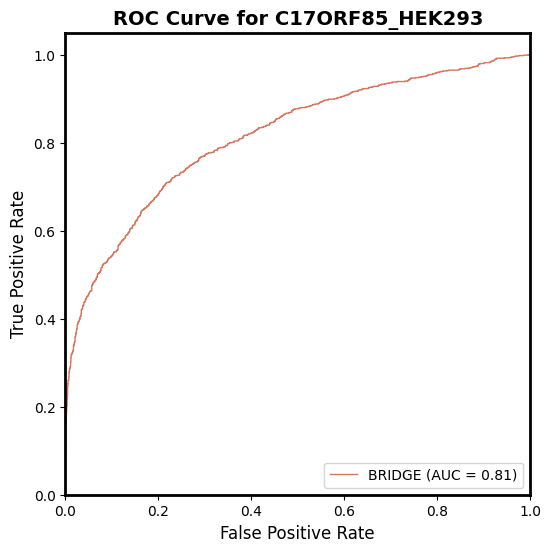

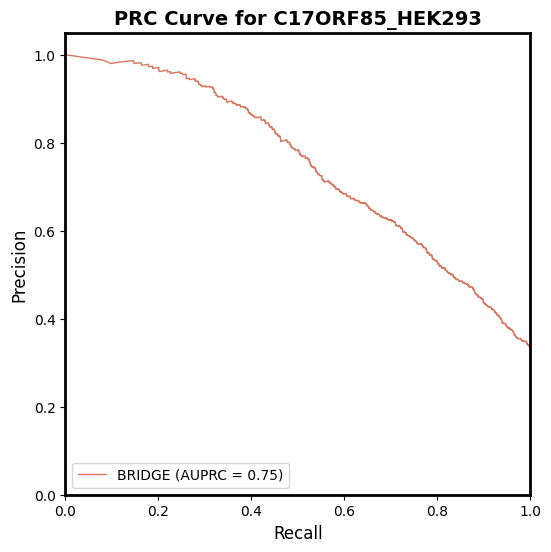

Some weights of BertModel were not initialized from the model checkpoint at RBPformer and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



===== Running: RTCB_HEK293 =====
[INFO] Encoded 15002 sequences for RTCB_HEK293, shape: (15002, 101, 99)
Valid motif file detected, skipping motif_prior
---------------------------------
Total params: 19111841
Trainable params: 19111809
Non-trainable params: 32
---------------------------------
[Saved] ./results/preds_cache/RTCB_HEK293_labels_preds.npz


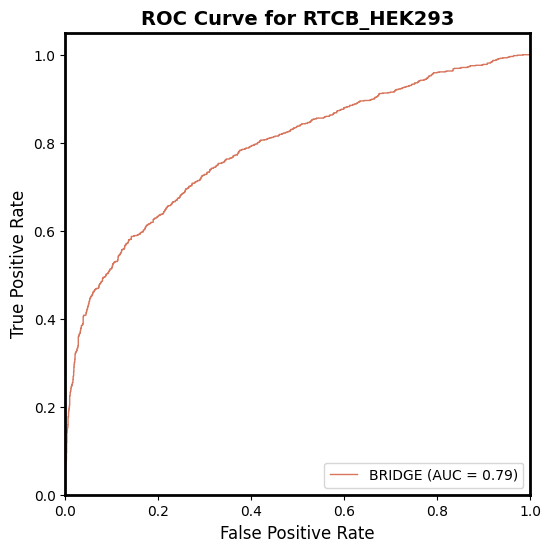

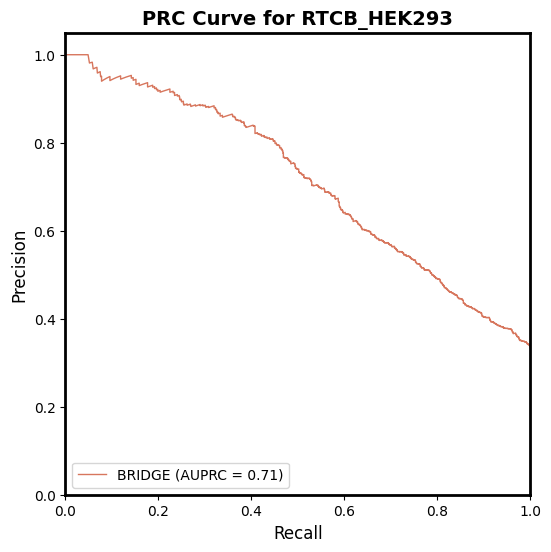

Some weights of BertModel were not initialized from the model checkpoint at RBPformer and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



===== Running: ELAVL1_HEK293 =====
[INFO] Encoded 15002 sequences for ELAVL1_HEK293, shape: (15002, 101, 99)
Valid motif file detected, skipping motif_prior
---------------------------------
Total params: 19111841
Trainable params: 19111809
Non-trainable params: 32
---------------------------------
[Saved] ./results/preds_cache/ELAVL1_HEK293_labels_preds.npz


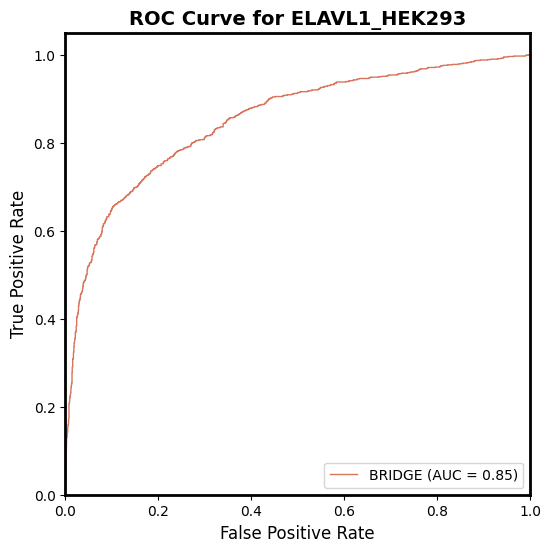

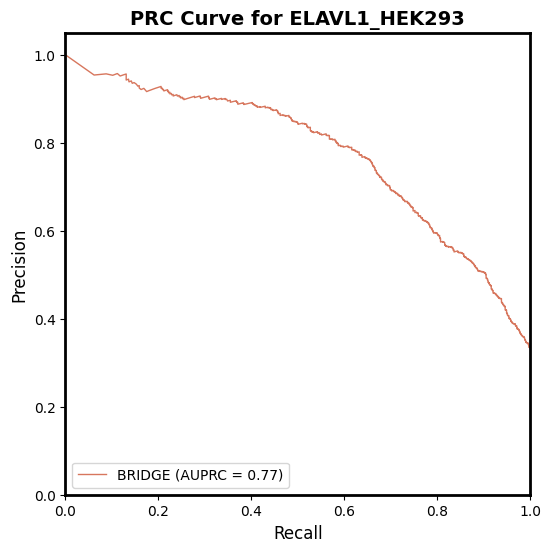


===== Running: CPSF3_HEK293 =====


Some weights of BertModel were not initialized from the model checkpoint at RBPformer and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[INFO] Encoded 15002 sequences for CPSF3_HEK293, shape: (15002, 101, 99)
Valid motif file detected, skipping motif_prior
---------------------------------
Total params: 19111841
Trainable params: 19111809
Non-trainable params: 32
---------------------------------
[Saved] ./results/preds_cache/CPSF3_HEK293_labels_preds.npz


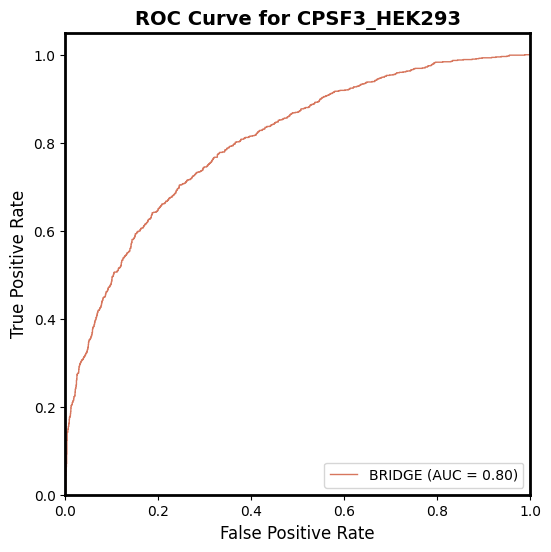

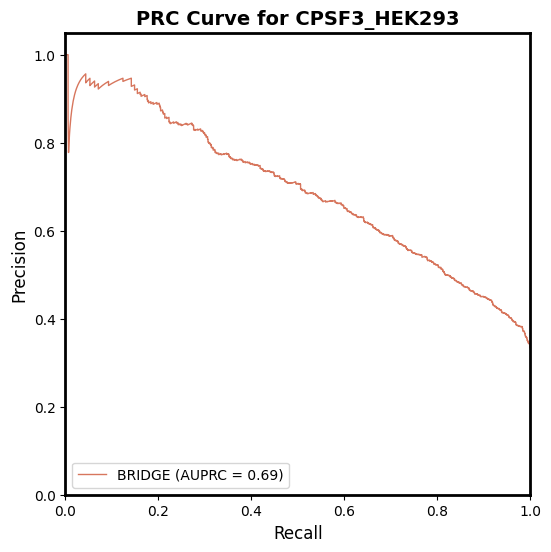

Some weights of BertModel were not initialized from the model checkpoint at RBPformer and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



===== Running: EFTUD2_HepG2 =====
[INFO] Encoded 15000 sequences for EFTUD2_HepG2, shape: (15000, 101, 99)
Valid motif file detected, skipping motif_prior
---------------------------------
Total params: 19111841
Trainable params: 19111809
Non-trainable params: 32
---------------------------------
[Saved] ./results/preds_cache/EFTUD2_HepG2_labels_preds.npz


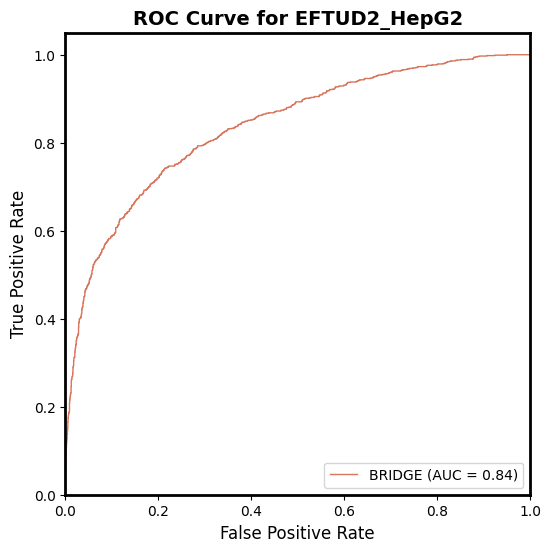

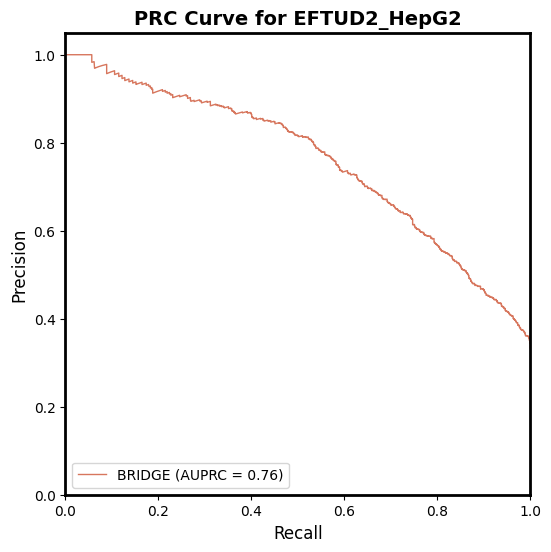


===== Running: SUPV3L1_HepG2 =====


Some weights of BertModel were not initialized from the model checkpoint at RBPformer and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[INFO] Encoded 15000 sequences for SUPV3L1_HepG2, shape: (15000, 101, 99)
Valid motif file detected, skipping motif_prior
---------------------------------
Total params: 19111841
Trainable params: 19111809
Non-trainable params: 32
---------------------------------
[Saved] ./results/preds_cache/SUPV3L1_HepG2_labels_preds.npz


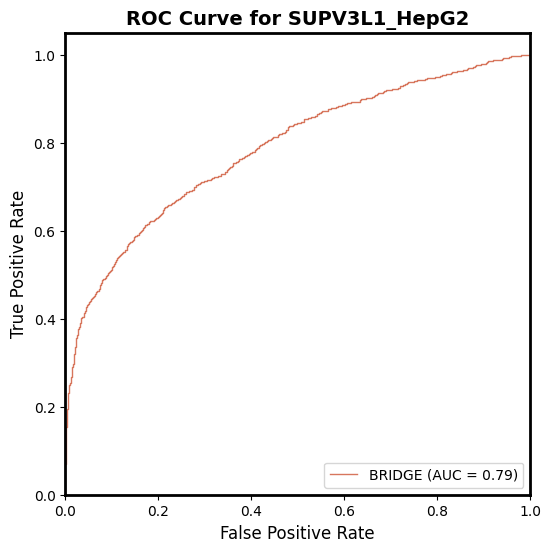

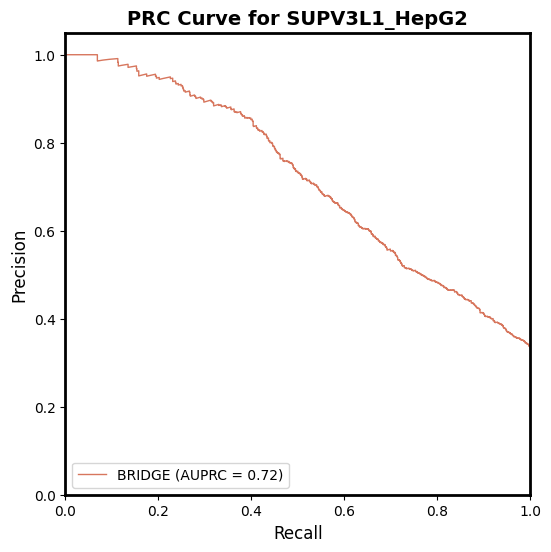

Some weights of BertModel were not initialized from the model checkpoint at RBPformer and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



===== Running: TBRG4_HepG2 =====
[INFO] Encoded 15000 sequences for TBRG4_HepG2, shape: (15000, 101, 99)
Valid motif file detected, skipping motif_prior
---------------------------------
Total params: 19111841
Trainable params: 19111809
Non-trainable params: 32
---------------------------------
[Saved] ./results/preds_cache/TBRG4_HepG2_labels_preds.npz


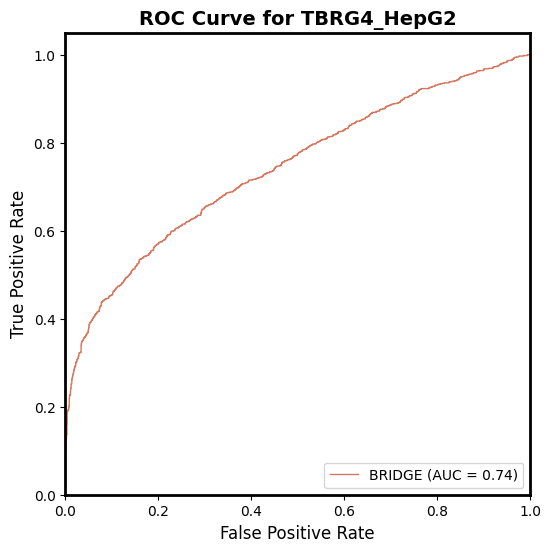

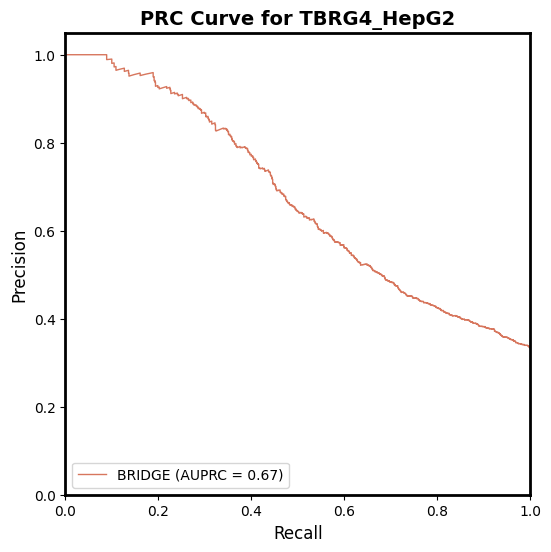

Some weights of BertModel were not initialized from the model checkpoint at RBPformer and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



===== Running: SF3A3_HepG2 =====
[INFO] Encoded 15002 sequences for SF3A3_HepG2, shape: (15002, 101, 99)
Valid motif file detected, skipping motif_prior
---------------------------------
Total params: 19111841
Trainable params: 19111809
Non-trainable params: 32
---------------------------------
[Saved] ./results/preds_cache/SF3A3_HepG2_labels_preds.npz


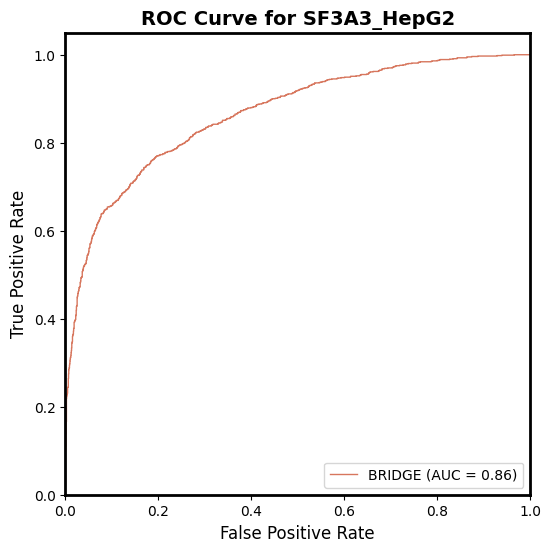

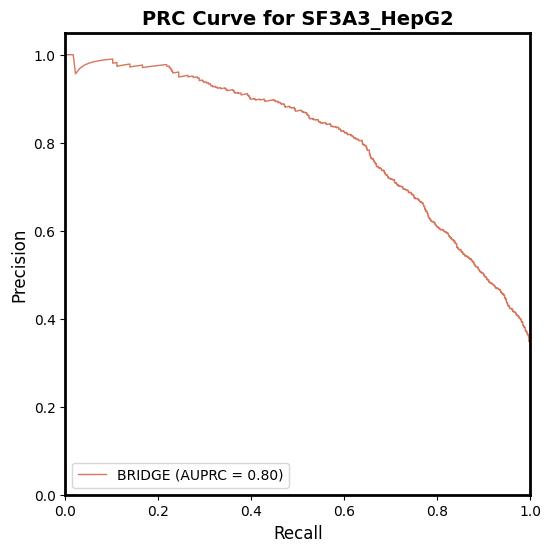

Some weights of BertModel were not initialized from the model checkpoint at RBPformer and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



===== Running: PRPF8_HepG2 =====
[INFO] Encoded 15002 sequences for PRPF8_HepG2, shape: (15002, 101, 99)
Valid motif file detected, skipping motif_prior
---------------------------------
Total params: 19111841
Trainable params: 19111809
Non-trainable params: 32
---------------------------------
[Saved] ./results/preds_cache/PRPF8_HepG2_labels_preds.npz


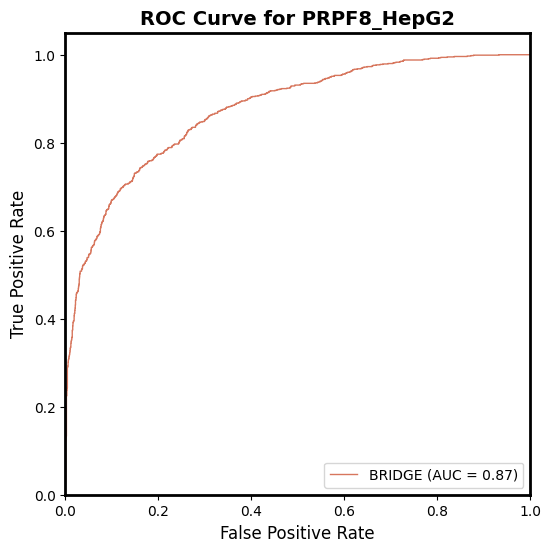

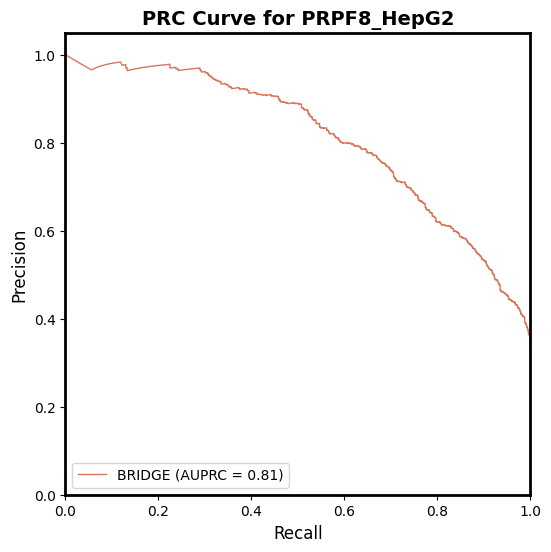

In [6]:
if __name__ == '__main__':
    seed = 42
    device_num = 3

    data_files = [
        "C17ORF85_HEK293",
        "RTCB_HEK293","ELAVL1_HEK293","CPSF3_HEK293",
        "EFTUD2_HepG2","SUPV3L1_HepG2","TBRG4_HepG2","SF3A3_HepG2","PRPF8_HepG2"
    ]

    data_path = "dataset"
    Transformer_path = "RBPformer"
    early_stopping = 20

    for df in data_files:
        data_file = df
        log_print(f"\n===== Running: {data_file} =====", color="cyan")

        main()
        torch.cuda.empty_cache()